In [ ]:
import pandas as pd

df = pd.read_csv("../dataset/customer_shopping_behavior.csv")

df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


# Data Understanding

The objective of this section is to understand the structure, size, and quality of the dataset before performing analysis.

In [ ]:
df.shape

(3900, 18)

In [ ]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='str')

In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

In [ ]:
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [ ]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


Dataset Summary
Rows: 3900
Columns: 18
Missing Values: 37 (Review Rating)



In [ ]:
df.duplicated().sum()

np.int64(0)

## Missing Value Treatment

The Review Rating column contains 37 missing values (less than 1% of total data). Missing values were replaced using the median rating to preserve dataset size and reduce bias.

In [ ]:
df['Review Rating'] = df['Review Rating'].fillna(
    df['Review Rating'].median()
)

In [ ]:
df['Review Rating'].isnull().sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Purchase Amount (USD)'].sum()

np.int64(233081)

In [ ]:
df['Purchase Amount (USD)'].mean()

np.float64(59.76435897435898)

## Revenue Analysis

### Key Findings

- The dataset contains 3,900 customer transactions.
- Total revenue generated is $233,081.
- The average purchase amount per transaction is $59.76.
- No duplicate records were found in the dataset.
- Missing values in Review Rating were treated using median imputation.

In [ ]:
category_sales = df.groupby('Category')['Purchase Amount (USD)'].sum()
category_sales.sort_values(ascending=False)

Category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: Purchase Amount (USD), dtype: int64

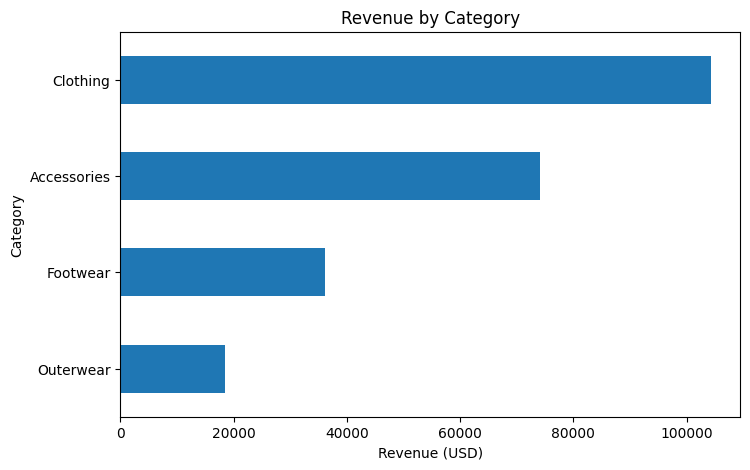

In [ ]:
import matplotlib.pyplot as plt

category_sales.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title('Revenue by Category')
plt.xlabel('Revenue (USD)')
plt.ylabel('Category')
plt.show()

In [ ]:
category_sales.sort_values(ascending=False)

Category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: Purchase Amount (USD), dtype: int64

## Category Performance Analysis

### Business Question
Which product categories generate the highest revenue?

### Key Findings

- Clothing is the highest revenue-generating category with $104,264 in sales.
- Accessories contribute $74,200 and represent the second-largest revenue source.
- Footwear generates moderate revenue at $36,093.
- Outerwear contributes the least revenue at $18,524.

### Business Recommendation

- Increase marketing investment for Clothing and Accessories categories.
- Ensure adequate inventory levels for top-performing categories.
- Investigate reasons for lower Outerwear sales and explore seasonal promotions.

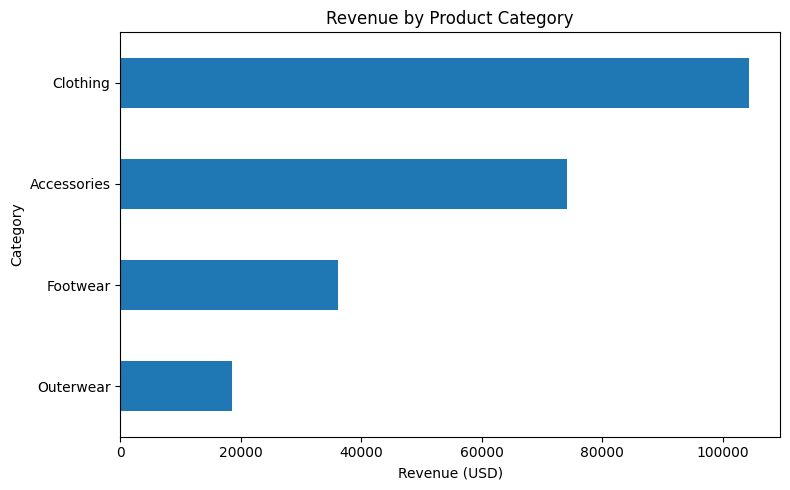

In [ ]:
import matplotlib.pyplot as plt

category_sales.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Revenue by Product Category")
plt.xlabel("Revenue (USD)")
plt.ylabel("Category")
plt.tight_layout()

plt.show()

## Gender-Based Revenue Analysis

### Business Question
Which gender contributes more to overall revenue?

### Objective
Understand purchasing behavior across gender segments and identify high-value customer groups.

In [ ]:
gender_sales = df.groupby('Gender')['Purchase Amount (USD)'].sum()

gender_sales

Gender
Female     75191
Male      157890
Name: Purchase Amount (USD), dtype: int64

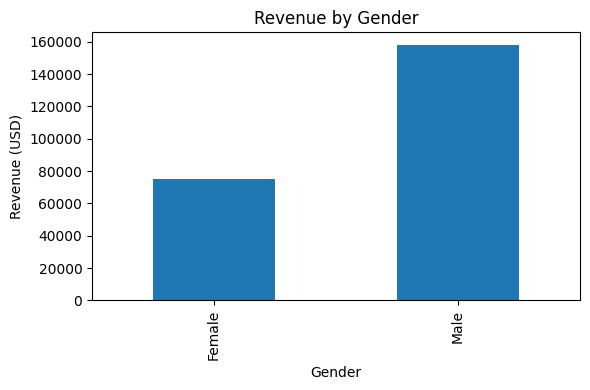

In [ ]:
import matplotlib.pyplot as plt

gender_sales.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Revenue by Gender")
plt.xlabel("Gender")
plt.ylabel("Revenue (USD)")
plt.tight_layout()

plt.show()

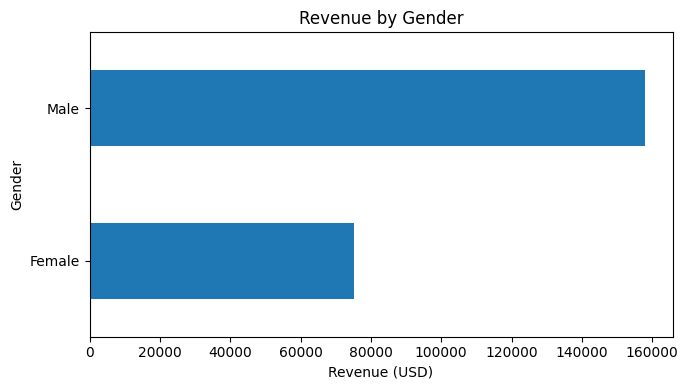

In [ ]:
gender_sales = df.groupby('Gender')['Purchase Amount (USD)'].sum().sort_values()

gender_sales.plot(
    kind='barh',
    figsize=(7,4)
)

plt.title("Revenue by Gender")
plt.xlabel("Revenue (USD)")
plt.ylabel("Gender")
plt.tight_layout()

plt.show()

In [ ]:
gender_count = df['Gender'].value_counts()

print(gender_count)

Gender
Male      2652
Female    1248
Name: count, dtype: int64


In [ ]:
df.groupby('Gender')['Purchase Amount (USD)'].mean()

Gender
Female    60.249199
Male      59.536199
Name: Purchase Amount (USD), dtype: float64

## Gender-Based Revenue Analysis

### Key Findings

- Male customers generated $157,890 in revenue.
- Female customers generated $75,191 in revenue.
- Male customers represent the majority of the customer base (2,652 customers).
- Female customers spend slightly more per transaction ($60.25) than male customers ($59.54).

### Business Recommendation

- Increase customer acquisition campaigns targeting female shoppers.
- Develop personalized promotions to improve engagement among both customer groups.
- Maintain marketing efforts toward male customers due to their larger contribution to total revenue.

In [ ]:
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[18,25,35,45,55,65,100],
    labels=[
        '18-25',
        '26-35',
        '36-45',
        '46-55',
        '56-65',
        '65+'
    ]
)

In [ ]:
age_sales = df.groupby('Age Group')['Purchase Amount (USD)'].sum()

age_sales

Age Group
18-25    30491
26-35    44342
36-45    43234
46-55    45619
56-65    44352
65+      20904
Name: Purchase Amount (USD), dtype: int64

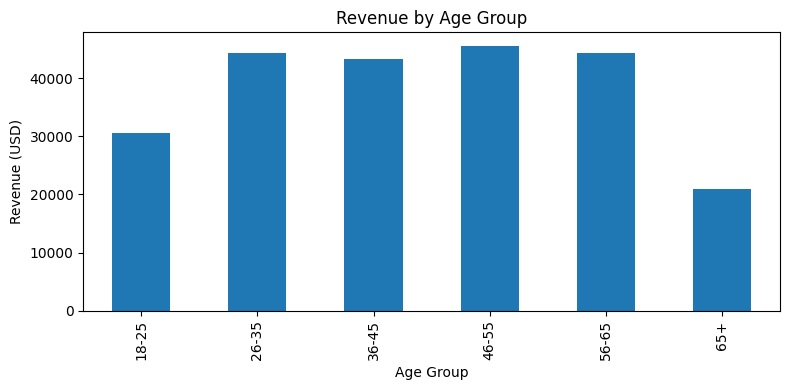

In [ ]:
import matplotlib.pyplot as plt

age_sales.plot(
    kind='bar',
    figsize=(8,4)
)

plt.title("Revenue by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Revenue (USD)")
plt.tight_layout()

plt.show()

In [ ]:
df.groupby('Age Group')['Purchase Amount (USD)'].mean()

Age Group
18-25    60.739044
26-35    59.760108
36-45    59.305898
46-55    60.583001
56-65    59.136000
65+      58.884507
Name: Purchase Amount (USD), dtype: float64

## Age Group Analysis

### Key Findings

- Customers aged 46–55 generate the highest revenue ($45,619).
- Customers aged 18–25 have the highest average purchase value ($60.74).
- Revenue contribution declines significantly for customers aged 65+.

### Business Recommendations

- Focus retention campaigns on customers aged 46–55.
- Create social media and digital campaigns targeting 18–25 customers.
- Evaluate whether specialized offers can improve engagement among customers aged 65+.

In [ ]:
season_sales = df.groupby('Season')['Purchase Amount (USD)'].sum()

season_sales.sort_values(ascending=False)

Season
Fall      60018
Spring    58679
Winter    58607
Summer    55777
Name: Purchase Amount (USD), dtype: int64

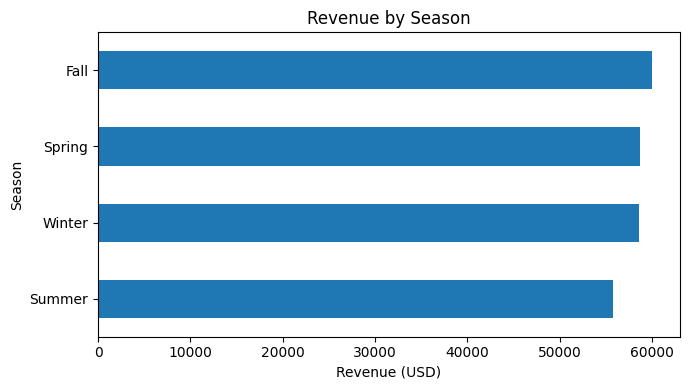

In [ ]:
import matplotlib.pyplot as plt

season_sales.sort_values().plot(
    kind='barh',
    figsize=(7,4)
)

plt.title("Revenue by Season")
plt.xlabel("Revenue (USD)")
plt.ylabel("Season")
plt.tight_layout()

plt.show()

In [ ]:
df.groupby('Season')['Purchase Amount (USD)'].mean()

Season
Fall      61.556923
Spring    58.737738
Summer    58.405236
Winter    60.357364
Name: Purchase Amount (USD), dtype: float64

## Seasonal Sales Analysis

### Business Question

Which season generates the highest revenue and customer spending?

### Key Findings

- Fall generated the highest revenue ($60,018).
- Spring generated $58,679 in revenue.
- Winter generated $58,607 in revenue.
- Summer generated the lowest revenue ($55,777).

### Average Purchase Value

- Fall has the highest average purchase value ($61.56).
- Winter customers spend $60.36 on average.
- Spring and Summer show slightly lower average spending.

### Business Recommendations

- Increase marketing campaigns during Fall season.
- Ensure sufficient inventory before Fall.
- Investigate why Summer sales are comparatively lower.

In [ ]:
payment_sales = df.groupby(
    'Payment Method'
)['Purchase Amount (USD)'].sum()

payment_sales.sort_values(
    ascending=False
)

Payment Method
Credit Card      40310
PayPal           40109
Cash             40002
Debit Card       38742
Venmo            37374
Bank Transfer    36544
Name: Purchase Amount (USD), dtype: int64

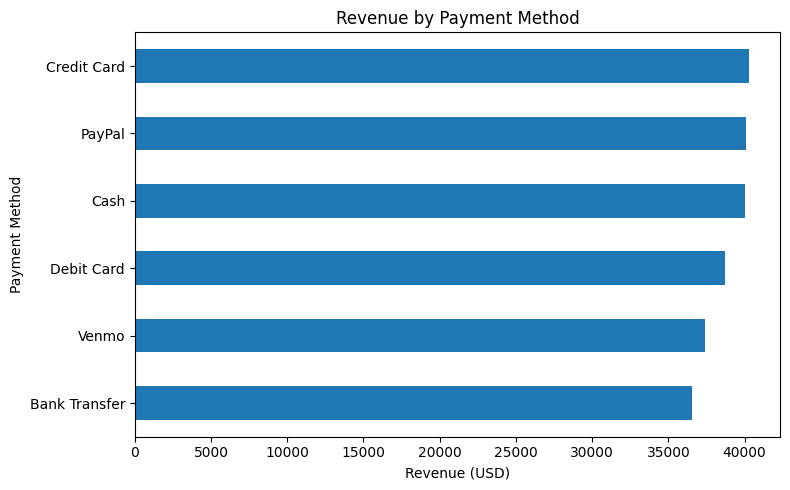

In [ ]:
import matplotlib.pyplot as plt

payment_sales.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title("Revenue by Payment Method")
plt.xlabel("Revenue (USD)")
plt.ylabel("Payment Method")
plt.tight_layout()

plt.show()

In [ ]:
subscription_analysis = df.groupby(
    'Subscription Status'
)['Previous Purchases'].mean()

subscription_analysis

Subscription Status
No     25.080436
Yes    26.084520
Name: Previous Purchases, dtype: float64

In [ ]:
df.groupby(
    'Subscription Status'
)['Purchase Amount (USD)'].sum()

Subscription Status
No     170436
Yes     62645
Name: Purchase Amount (USD), dtype: int64

In [ ]:
discount_analysis = df.groupby(
    'Discount Applied'
)['Purchase Amount (USD)'].mean()

discount_analysis

Discount Applied
No     60.130454
Yes    59.279070
Name: Purchase Amount (USD), dtype: float64

In [ ]:
df['Discount Applied'].value_counts()

Discount Applied
No     2223
Yes    1677
Name: count, dtype: int64

In [ ]:
promo_analysis = df.groupby(
    'Promo Code Used'
)['Purchase Amount (USD)'].mean()

promo_analysis

Promo Code Used
No     60.130454
Yes    59.279070
Name: Purchase Amount (USD), dtype: float64

In [ ]:
rating_analysis = df.groupby(
    'Review Rating'
)['Purchase Amount (USD)'].mean()

rating_analysis
rating_analysis.sort_index()

Review Rating
2.5    62.287879
2.6    59.765823
2.7    59.363636
2.8    57.066176
2.9    56.198795
3.0    60.728395
3.1    58.782051
3.2    61.315789
3.3    59.794521
3.4    59.005495
3.5    58.072368
3.6    57.081633
3.7    59.228188
3.8    61.887640
3.9    58.913580
4.0    59.237569
4.1    61.959459
4.2    60.757396
4.3    59.673469
4.4    60.525316
4.5    59.489209
4.6    57.311765
4.7    59.283784
4.8    61.881944
4.9    63.746914
5.0    64.352941
Name: Purchase Amount (USD), dtype: float64

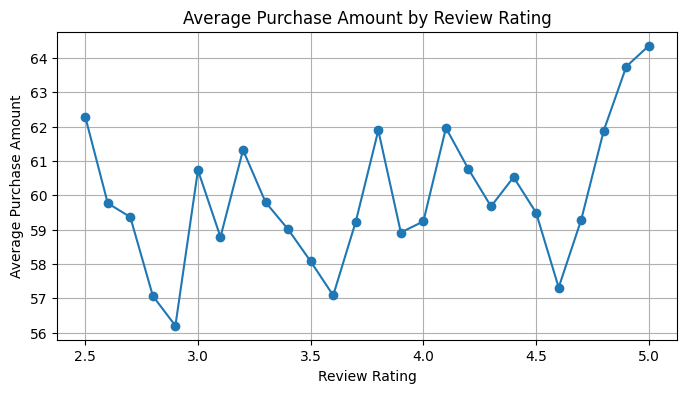

In [ ]:
rating_analysis.plot(
    kind='line',
    marker='o',
    figsize=(8,4)
)

plt.title("Average Purchase Amount by Review Rating")
plt.xlabel("Review Rating")
plt.ylabel("Average Purchase Amount")
plt.grid(True)

plt.show()

In [ ]:
shipping_analysis = df.groupby(
    'Shipping Type'
)['Purchase Amount (USD)'].sum()

shipping_analysis.sort_values(
    ascending=False
)

Shipping Type
Free Shipping     40777
Express           39067
Store Pickup      38931
Standard          38233
2-Day Shipping    38080
Next Day Air      37993
Name: Purchase Amount (USD), dtype: int64

## Customer Satisfaction Analysis

### Business Question

Do highly satisfied customers spend more money?

### Key Findings

- Customers with higher review ratings generally tend to spend more.
- Customers giving a rating of 5.0 have the highest average purchase value ($64.35).
- Customers giving a rating of 4.9 spend $63.75 on average.
- Lower ratings such as 2.8 and 2.9 are associated with lower average purchase values.

### Business Insights

- Customer satisfaction appears to have a positive relationship with spending behavior.
- Highly satisfied customers are more likely to become valuable customers.
- Improving customer experience may contribute to higher customer spending.

### Business Recommendations

- Improve customer support and post-purchase experience.
- Reward highly satisfied customers through loyalty programs.
- Investigate the reasons behind lower ratings and address customer pain points.

## Shipping Method Analysis

### Business Question

Which shipping methods generate the highest revenue?

### Key Findings

- Free Shipping generated the highest revenue ($40,777).
- Express Shipping generated $39,067.
- Store Pickup generated $38,931.
- Revenue is relatively evenly distributed across shipping methods.

### Business Insights

- Customers strongly prefer Free Shipping.
- Faster shipping options such as Express and Next Day Air continue to generate significant revenue.
- Shipping flexibility appears to be important for customer satisfaction.

### Business Recommendations

- Continue offering Free Shipping as a customer acquisition and retention strategy.
- Promote premium shipping options for customers requiring faster delivery.
- Optimize shipping costs while maintaining multiple delivery choices.

In [ ]:
# Fill missing ratings
df['Review Rating'] = df['Review Rating'].fillna(df['Review Rating'].mean())

# Save cleaned dataset
df.to_csv("cleaned_customer_shopping_behavior.csv", index=False)

print("Cleaned file saved successfully!")

Cleaned file saved successfully!


In [ ]:
cat_cols = [
    'Gender',
    'Category',
    'Season',
    'Subscription Status',
    'Discount Applied',
    'Promo Code Used',
    'Payment Method',
    'Shipping Type',
    'Frequency of Purchases'
]

for col in cat_cols:
    df[col] = df[col].astype('category')

# Check data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   Customer ID             3900 non-null   int64   
 1   Age                     3900 non-null   int64   
 2   Gender                  3900 non-null   category
 3   Item Purchased          3900 non-null   str     
 4   Category                3900 non-null   category
 5   Purchase Amount (USD)   3900 non-null   int64   
 6   Location                3900 non-null   str     
 7   Size                    3900 non-null   str     
 8   Color                   3900 non-null   str     
 9   Season                  3900 non-null   category
 10  Review Rating           3900 non-null   float64 
 11  Subscription Status     3900 non-null   category
 12  Shipping Type           3900 non-null   category
 13  Discount Applied        3900 non-null   category
 14  Promo Code Used         3900 non-nu

In [ ]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750538,25.351538
std,1125.977353,15.207589,23.685392,0.713589,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [ ]:
df.describe(include='object')

C:\Users\capit\AppData\Local\Temp\ipykernel_20400\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,Item Purchased,Location,Size,Color
count,3900,3900,3900,3900
unique,25,50,4,25
top,Blouse,Montana,M,Olive
freq,171,96,1755,177


In [ ]:
df.to_csv(
    "cleaned_customer_shopping_behavior.csv",
    index=False
)